# AI 06a Iris

> 학번:2020123285
>
> 이름:LI,YAQING

---


### 1. Prepare Data

---

**붓꽃 분류 문제**

- 붓꽃의 4가지 속성 (꽃받침의 길이와 너비, 꽃잎의 길이와 너비)을 사용하여 3개의 붓꽃 종류 (Setosa, Versicolour, Virginica) 를 분류하는 문제
- 총 150개의 데이터 중 각 분류마다 50개
- Train set - 120, Test set - 30
- 코드에서 다음 3가지 항목들을 변경해보며 test 정확도를 향상:

1. 신경망의 층 수와 노드 수 (Edit 1)
2. 학습률 (Edit 2)
3. 반복횟수 (Edit 3)

- **결과의 마지막 10개 행에서 test accuracy가 한번이라도 0.95 이상이면 통과**


### Iris dataset

This is perhaps the best known database to be found in the pattern recognition literature. Fisher's paper is a classic in the field and is referenced frequently to this day. (See Duda & Hart, for example.) The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant. One class is linearly separable from the other 2; the latter are NOT linearly separable from each other.

Predicted attribute: class of iris plant.


### Number of Instances:

150 (50 in each of three classes)

### Attribute Information:

4 numeric, predictive attributes and the class

* sepal(꽃받침) length in cm
* sepal(꽃받침) width in cm
* petal(꽃잎) length in cm
* petal(꽃잎) width in cm

### Classes:

- Iris Setosa
- Iris Versicolour
- Iris Virginica

### Class Distribution

33.3% for each of 3 classes.




In [1]:
# ai06_lib 모듈 다운로드
# 일정 시간이 지나서 Colab 런타임과의 연결이 끊어졌다면 다운로드 했던 파일도 사라지기 때문에 다시 다운로드해야 합니다.

!wget https://ycs-class.s3.ap-northeast-2.amazonaws.com/modules/ai06_lib.py

--2024-10-30 03:49:15--  https://ycs-class.s3.ap-northeast-2.amazonaws.com/modules/ai06_lib.py
Resolving ycs-class.s3.ap-northeast-2.amazonaws.com (ycs-class.s3.ap-northeast-2.amazonaws.com)... 3.5.188.145, 52.219.148.94, 3.5.188.167, ...
Connecting to ycs-class.s3.ap-northeast-2.amazonaws.com (ycs-class.s3.ap-northeast-2.amazonaws.com)|3.5.188.145|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14372 (14K) [binary/octet-stream]
Saving to: ‘ai06_lib.py’

ai06_lib.py         100%[===================>]  14.04K  --.-KB/s    in 0s      

2024-10-30 03:49:16 (109 MB/s) - ‘ai06_lib.py’ saved [14372/14372]



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn import datasets

from ai06_lib import *

In [3]:
# 데이터셋 로드

iris = datasets.load_iris()

# sepal length in cm, sepal width in cm
X = iris.data
Y = iris.target

pool = np.arange(X.shape[0])
np.random.shuffle(pool)

train_mask = pool[:120]
test_mask = pool[120:]

x_train = X[train_mask]
y_train = Y[train_mask]

x_test = X[test_mask]
y_test = Y[test_mask]

print("train data : ", x_train.shape)
print("train label : ", y_train.shape)
print("test data : ", x_test.shape)
print("test label : ", y_test.shape)


train data :  (120, 4)
train label :  (120,)
test data :  (30, 4)
test label :  (30,)


In [4]:
# Train set에 어떤 내용이 들어있는지 확인

print( 'x_train')
print( x_train[:5] )
print( 'y_train')
print( y_train[:5] )

x_train
[[4.4 2.9 1.4 0.2]
 [6.7 3.3 5.7 2.1]
 [6.4 2.8 5.6 2.2]
 [5.1 3.8 1.9 0.4]
 [5.8 2.7 3.9 1.2]]
y_train
[0 2 2 0 1]


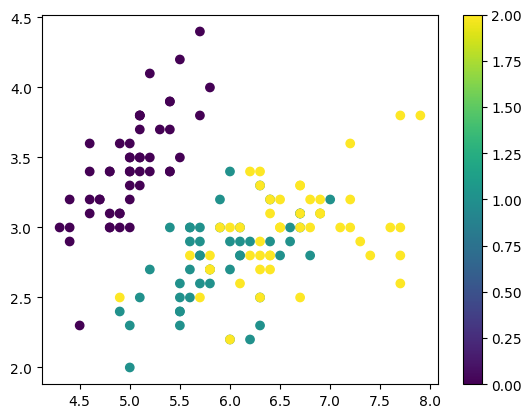

In [5]:
# 속성 중 첫 번째, 두 번째만 사용하여 분류를 그래프로 표현

plt.scatter(X[:, 0], X[:, 1], c = Y)
plt.colorbar()
plt.show()

### 2. Define and Train Model

---

In [14]:
# hidden_size_list 를 변경하여 신경망의 노드 수나 층 수를 지정할 수 있습니다. (Edit 1)

# 입력층 노드 4개, 출력층 노드 3개는 고정이므로 은닉층의 갯수와 노드 수를 지정해주면 됩니다.

# 예시) 2층 신경망 (은닉층1 노드 2개)
# hidden_size_list=[2]

# 예시) 3층 신경망 (은닉층1 노드 3개, 은닉층2 노드 3개)
# hidden_size_list=[3, 3]

# 예시) 4층 신경망 (은닉층1 노드 5개, 은닉층2 노드 3개, 은닉층3 노드 2개)
# hidden_size_list=[5, 3, 2]

# 힌트) 노드 갯수가 너무 작으면 학습이 잘 안됨


hidden_size_list = [15, 30, 15]

net = MultiLayerNet( input_size=x_train.shape[1], hidden_size_list = hidden_size_list, output_size=3, activation='relu', weight_init_std='he' )



# 학습률을 바꿀 수 있습니다. (Edit 2)
# 0.1, 0.01, 0.001, 0.0001 등 여러 값을 시도해보세요.

# 힌트) 학습률이 너무 크면 학습이 잘 안될 수 있습니다.

learning_rate = 0.001

train_loss_list = []
train_acc_list = []
test_acc_list = []


# 반복 횟수를 바꿀 수 있습니다. (Edit 3)
# 정확도가 계속 증가할 여지가 있다면 반복 횟수를 늘릴 필요가 있습니다.

# 힌트) 반복 횟수는 일단 충분한 값을 써보면 되겠습니다.

for i in range(300):

    # 기울기 계산
    grad = net.gradient(x_train, y_train)

    # 가중치 갱신
    for key in net.params:
        net.params[key] -= learning_rate * grad[key]

    # 손실 계산
    loss = net.loss(x_train, y_train)

    train_loss_list.append(loss)

    # 정확도 출력 빈도 변경 가능
    if i % 10 == 0:
        train_acc = net.accuracy(x_train, y_train)
        test_acc = net.accuracy(x_test, y_test)
        train_acc_list.append( train_acc )
        test_acc_list.append( test_acc )
        print('iter: {} loss: {} test accuracy: {:.4f} train accuracy: {:.4f}'.format(i, loss, net.accuracy(x_test, y_test), net.accuracy(x_train, y_train) ))



iter: 0 loss: 1.3507832797829793 test accuracy: 0.4667 train accuracy: 0.6083
iter: 10 loss: 1.068085122071644 test accuracy: 0.5667 train accuracy: 0.6167
iter: 20 loss: 0.8707617780766039 test accuracy: 0.6000 train accuracy: 0.6167
iter: 30 loss: 0.7580758542549751 test accuracy: 0.6000 train accuracy: 0.6167
iter: 40 loss: 0.709857379852823 test accuracy: 0.6000 train accuracy: 0.6167
iter: 50 loss: 0.6897053260780761 test accuracy: 0.6000 train accuracy: 0.6167
iter: 60 loss: 0.6775671365466995 test accuracy: 0.6000 train accuracy: 0.6167
iter: 70 loss: 0.6674283013855179 test accuracy: 0.6000 train accuracy: 0.6333
iter: 80 loss: 0.6579684882151746 test accuracy: 0.6000 train accuracy: 0.7000
iter: 90 loss: 0.6489132522080595 test accuracy: 0.6000 train accuracy: 0.7500
iter: 100 loss: 0.6402673874910919 test accuracy: 0.7667 train accuracy: 0.8000
iter: 110 loss: 0.6318559447657534 test accuracy: 0.8333 train accuracy: 0.8333
iter: 120 loss: 0.6236128171896539 test accuracy: 0.8

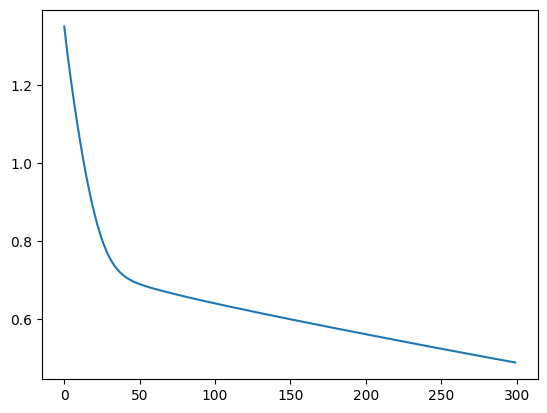

In [15]:
# 손실 함수 값의 변화

plt.plot(train_loss_list)
plt.show()

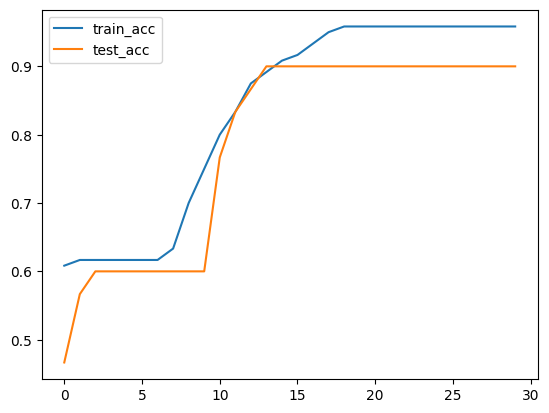

In [16]:
# Train set, test set 정확도 추이

plt.plot(train_acc_list, label='train_acc')
plt.plot(test_acc_list, label='test_acc')
plt.legend()
plt.show()

### 3. Test Model

---

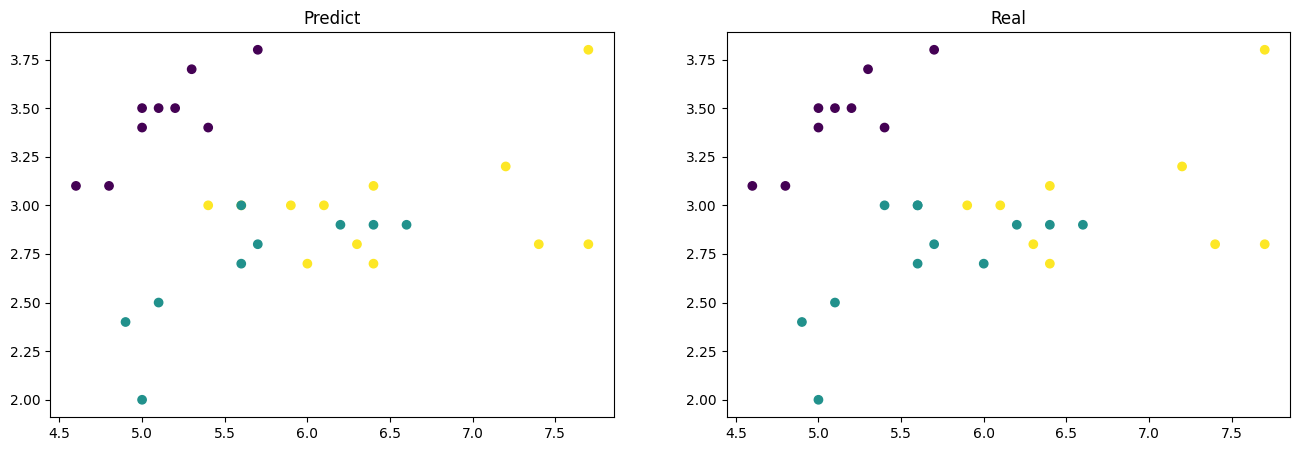

In [17]:
# 속성 중 두 개만 사용하여 예측 값을 실제와 비교하는 그래프

o_test = net.predict(x_test)
o_test = np.argmax(o_test, axis=1)

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

ax1.scatter(x_test[:, 0], x_test[:, 1], c = o_test)
ax2.scatter(x_test[:, 0], x_test[:, 1], c = y_test)

ax1.set_title('Predict')
ax2.set_title('Real')

plt.show()